# Reconstruction

Keyframes go in; a point cloud with one camera pose and intrinsics per frame comes out.
This page reads the feedforward reconstruction the pipeline already made for the shared
scene, builds a second one by structure from motion (SfM), and then judges both without
ground truth by checking how well the views agree with each other.

In [1]:
import contextlib
import io
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pycolmap
import pyvista as pv

from collab_splats.geometry.metrics import compute_reconstruction_quality
from collab_splats.geometry.transforms import invert_poses
from collab_splats.pointcloud.sfm import InstantSfMCreator
from collab_splats.pointcloud.utils import clean_pointcloud
from collab_splats.utils.visualization import (
    create_camera_frustum_pyvista,
    pointcloud_to_polydata,
)

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud", "reconstruction_quality_report")

## 1. Feedforward reconstruction

A feedforward model predicts depth and a camera for every keyframe in one network pass.
The shared scene uses VGGT-Omega. VGGT-X, MapAnything and LoGeR plug in the same way.

The pointcloud stage calls `get_creator("vggt_omega")`, which returns the
`VGGTOmegaCreator` class, builds it from the `pointcloud` config block and calls
`create_pointcloud(images_dir, backend_dir, colmap_model_dir)`. That writes
`pointcloud.zarr`, a COLMAP model and `sparse_pc.ply`. The inference already ran in setup,
so this page reads its output instead of running the model again.

`scene.result` loads the stage's `pointcloud.zarr` as a `PointcloudResult`. It carries the
points with their colors, and per frame a world-to-camera pose (OpenCV axes), two
intrinsics, the source image path and the crop box that maps the frame onto the model grid.
The dense per-pixel maps (depth, confidence, world points) stay on disk here.

In [2]:
result = scene.result

print("points     :", result.points.shape, result.points.dtype)
print("colors     :", result.colors.shape, result.colors.dtype)
print("extrinsics :", result.extrinsics.shape)
print("frames     :", len(result.image_paths))
print("model grid :", result.model_width, "x", result.model_height)
print("crop box   :", result.original_coords[0])

points     : (500000, 3) float32
colors     : (500000, 3) uint8
extrinsics : (96, 4, 4)
frames     : 96
model grid : 384 x 688
crop box   : [   0.    0. 1080. 1920. 1080. 1920.]


The two intrinsics describe the same camera on two pixel grids. `intrinsics` is for the
full-resolution source frame. `model_intrinsics` is for the smaller model grid that depth
and confidence live on. Pair each with data on its own grid: fusing model-grid depth with
full-resolution intrinsics gives a collapsed mesh.

In [3]:
full_k = np.round(result.intrinsics[0], 1)
model_k = np.round(result.model_intrinsics[0], 1)

# Same camera, two grids: focal and principal point scale with the resolution
k_table = pd.DataFrame({"intrinsics": list(full_k), "model_intrinsics": list(model_k)})
display(k_table)

,intrinsics,model_intrinsics
0,"[1572.1, 0.0, 540.0]","[559.0, 0.0, 192.0]"
1,"[0.0, 1566.9, 960.0]","[0.0, 561.5, 344.0]"
2,"[0.0, 0.0, 1.0]","[0.0, 0.0, 1.0]"


`clean_pointcloud` removes statistical outliers and then caps the point count at random.
It takes a result and returns a new one. The stage has already cleaned this cloud, so here
it only thins the points for display.

In [4]:
display_cloud = clean_pointcloud(result, remove_outliers=False, max_points=200_000)
print(f"{len(result.points):,} -> {len(display_cloud.points):,} points")

500,000 -> 200,000 points


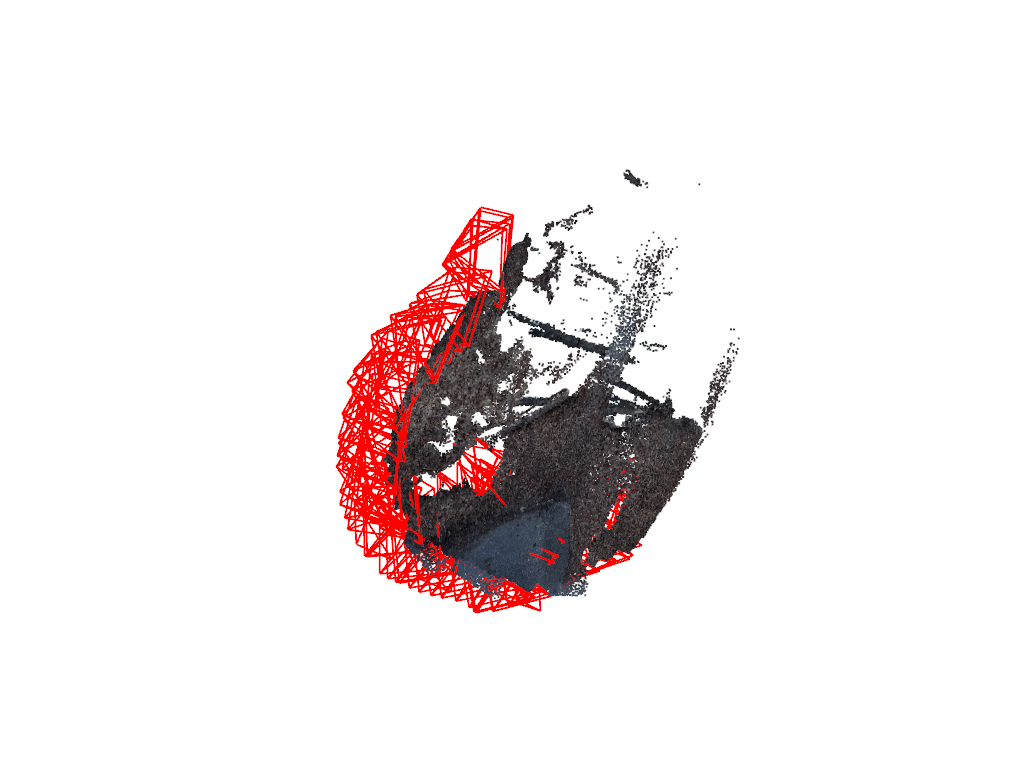

In [5]:
cloud = pointcloud_to_polydata(display_cloud.points, rgb=display_cloud.colors)

plotter = pv.Plotter()
plotter.add_mesh(cloud, scalars="rgb", rgb=True, point_size=2)

# Frustum size from the camera trajectory; feedforward units are arbitrary
cam_to_world = invert_poses(display_cloud.extrinsics)
centers = cam_to_world[:, :3, 3]
extent = np.ptp(centers, axis=0).max()
frustum_scale = 0.02 * extent

# One frustum per world-to-camera pose
for w2c in display_cloud.extrinsics:
    frustum = create_camera_frustum_pyvista(w2c, scale=frustum_scale)
    plotter.add_mesh(frustum, color="red", line_width=2)

plotter.show()

The red frustums should trace the path the camera walked, and the points should form
surfaces in front of them rather than a diffuse cloud.

## 2. Structure from motion

InstantSfM matches features between frames and solves all poses together. Its sparse
model is too thin to mesh, so inside `create_pointcloud` the creator also estimates metric
depth per frame with Video-Depth-Anything and scales it to the SfM model. The result is a
`PointcloudResult` like the feedforward one, so every later stage reads either.

SfM only registers frames it can match to a neighbor, so it needs more overlap between
keyframes than the feedforward model does. The result holds the registered frames only.
SfM also refuses bundle adjustment and loop closure, which are feedforward only.

In [6]:
sfm_dir = work_dir("reconstruction")
sfm = InstantSfMCreator(random_seed=0)

# InstantSfM and COLMAP print every phase and frame; keep the page to the summary below
pycolmap.logging.minloglevel = 2
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    sfm_result = sfm.create_pointcloud(scene.images_dir, sfm_dir)

# Registration, then the per-frame scale from depth model to SfM units
registered = sfm.attrs["registered_frames"]
total = sfm.attrs["total_frames"]
scales = np.asarray(sfm.attrs["depth_scales"])
median_scale = np.median(scales)
print(f"{registered} of {total} frames registered, {len(sfm_result.points):,} points")
scale_range = f"{scales.min():.2f}-{scales.max():.2f}"
print(f"depth scale: median {median_scale:.2f}, range {scale_range}")

81 of 96 frames registered, 14,313 points
depth scale: median 5.49, range 4.64-8.24


A depth scale that varies a lot across frames means the depth model and the SfM model
disagree about the scene's shape, not only its size.

## 3. Judging a reconstruction

A handheld capture has no ground truth, so the views check each other. Every frame's depth
is projected into every other frame, and where two views see the same surface their depths
should agree. The `reconstruction_quality_report` stage runs no model and no matcher: it
reads `pointcloud.zarr` and the keyframes and writes four tables to
`reconstruction_quality_report.json`.

- `frames`: one row per frame, with `multiview_agreement` (the share of its pixels another
  view agrees with) and `median_abs_rel_depth_error` over the pairs that touch it.
- `depth_pairs`: one row per ordered pair of overlapping frames, with the median and IQR
  relative depth error, the median parallax and the overlap in pixels.
- `depth_residual_histogram`: every overlapping pixel's relative residual, pre-binned.
- `photometric_pairs`: color agreement (NCC) between overlapping views; null when no
  frames are given.

Agreement uses a 5% relative band. The creators have an optional multiview filter
(`pointcloud.min_views`, off by default) with a tighter 1% band; the looser band here keeps
disagreement in the statistics when that filter is on.

In [7]:
report_path = scene.outputs["reconstruction_quality_report"]
report = json.loads(report_path.read_text())
print(json.dumps(report["scene"], indent=2))

# Frames the other views agree with least come first
ff_frames = pd.DataFrame(report["frames"])
worst = ff_frames.sort_values("multiview_agreement").head(5)
display(worst.round(3))

{
  "backend": "vggt_omega",
  "n_frames": 96,
  "model_resolution": "384x688",
  "image_width": 1080,
  "zarr": "/workspace/collab-splats/.worktrees/tutorial-rework/data/tutorial_scene/vggt_omega/pointcloud.zarr",
  "min_pair_overlap": 0.0
}


,frame_idx,covered_fraction,median_abs_rel_depth_error,multiview_agreement,confidence_median
65,1468,1.0,0.033,0.732,5.820
44,949,1.0,0.030,0.889,6.756
40,859,1.0,0.024,0.892,7.367
41,884,1.0,0.023,0.898,7.998
0,0,1.0,0.022,0.901,15.486


The stage is a thin file layer over `compute_reconstruction_quality`, which takes arrays.
Calling it directly on the in-memory SfM result needs no zarr. SfM gives no confidence, and
passing no frames sets the photometric table to None.

In [8]:
sfm_names = []
for image_path in sfm_result.image_paths:
    sfm_names.append(image_path.name)

sfm_tables = compute_reconstruction_quality(
    sfm_result.depth,
    sfm_result.model_intrinsics,
    sfm_result.intrinsics,
    sfm_result.extrinsics,
    sfm_result.original_coords,
    sfm_names,
    sfm_result.confidence,
    None,
)
print("photometric:", sfm_tables["photometric_pairs"])

photometric: None


The figure compares the two routes: agreement per frame, the pooled residual histogram, and
each pair's parallax against its depth error. The histogram's x axis is the residual mapped
through r / (1 + |r|), so the tails stay on the axis. The two routes see different pixel
counts, so the histogram is plotted as a density.

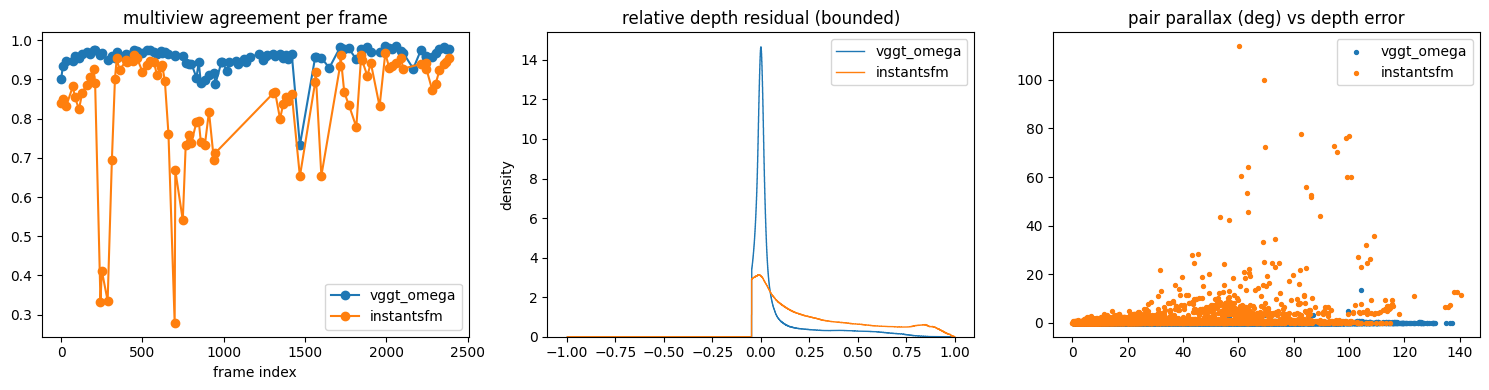

In [9]:
routes = {"vggt_omega": report, "instantsfm": sfm_tables}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# One line, one histogram and one scatter per route
for label, tables in routes.items():
    frames_df = pd.DataFrame(tables["frames"])
    pairs_df = pd.DataFrame(tables["depth_pairs"])
    hist = tables["depth_residual_histogram"]
    counts = np.asarray(hist["counts"])
    edges = np.asarray(hist["bin_edges"])
    widths = np.diff(edges)
    density = counts / counts.sum() / widths

    # SfM may register a subset, so plot against source frame index
    frame_idx = frames_df["frame_idx"].to_numpy()
    agreement = frames_df["multiview_agreement"].to_numpy()
    axes[0].plot(frame_idx, agreement, "o-", label=label)
    axes[1].stairs(density, edges, label=label)
    parallax = pairs_df["median_parallax_deg"]
    error = pairs_df["median_rel_depth_error"]
    axes[2].scatter(parallax, error, s=8, label=label)

# Titles, labels and legends
axes[0].set_xlabel("frame index")
axes[1].set_ylabel("density")
titles = [
    "multiview agreement per frame",
    "relative depth residual (bounded)",
    "pair parallax (deg) vs depth error",
]
for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.legend()

plt.tight_layout()

Agreement near 1 with a narrow histogram means the views confirm each other. A single frame
with low agreement is one the others do not see the same way, which usually points to a bad
pose. Large error at low parallax is expected, because depth is poorly constrained when the
camera barely moved between two views; large error at high parallax is a real disagreement.

## In a pipeline run

The `pointcloud` stage picks its route from `method` and `backend`, and the
`reconstruction_quality_report` stage writes the report beside `pointcloud.zarr`. SfM is
experimental and warns when selected; its creator settings sit in a block named after the
backend.

```yaml
pointcloud:
  method: feedforward     # feedforward | sfm
  backend: vggt_omega     # vggt_omega | vggtx | mapanything | loger
                          # sfm: instantsfm | colmap | hloc
  instantsfm:
    random_seed: 0
reconstruction_quality_report:
  min_pair_overlap: 0.0   # 0 keeps every ordered pair
```